In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(
    "archive (4)/US_Accidents_March23.csv",
    nrows=50000
)

In [4]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
df.shape

(50000, 46)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     50000 non-null  object 
 1   Source                 50000 non-null  object 
 2   Severity               50000 non-null  int64  
 3   Start_Time             50000 non-null  object 
 4   End_Time               50000 non-null  object 
 5   Start_Lat              50000 non-null  float64
 6   Start_Lng              50000 non-null  float64
 7   End_Lat                0 non-null      float64
 8   End_Lng                0 non-null      float64
 9   Distance(mi)           50000 non-null  float64
 10  Description            50000 non-null  object 
 11  Street                 50000 non-null  object 
 12  City                   50000 non-null  object 
 13  County                 50000 non-null  object 
 14  State                  50000 non-null  object 
 15  Zi

In [7]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,50000.00000,50000.000000,50000.000000,0.0,0.0,50000.000000,49544.000000,2497.000000,49361.000000,49694.000000,49474.000000,41578.000000,3276.000000
mean,2.39678,37.396862,-120.736826,NaN,NaN,0.014660,64.975323,39.050541,61.719394,29.981206,9.384875,8.736789,0.026529
std,0.49225,1.553001,4.750326,NaN,NaN,0.354411,13.200795,14.914320,21.706796,0.195356,1.958316,4.475498,0.050507
min,1.00000,32.544304,-123.813927,NaN,NaN,0.000000,3.900000,-8.400000,4.000000,3.010000,0.100000,0.000000,0.000000
25%,2.00000,37.343647,-122.127098,NaN,NaN,0.000000,55.900000,33.400000,46.000000,29.900000,10.000000,5.800000,0.000000
50%,2.00000,37.776711,-121.828537,NaN,NaN,0.000000,64.400000,39.000000,63.000000,29.970000,10.000000,8.100000,0.010000
75%,3.00000,38.409191,-121.272102,NaN,NaN,0.010000,73.400000,42.500000,78.000000,30.070000,10.000000,11.500000,0.030000
max,4.00000,41.428753,-81.550728,NaN,NaN,51.130000,113.000000,101.000000,100.000000,33.040000,80.000000,142.700000,0.550000


In [8]:
df.isnull().sum()

ID                           0
Source                       0
Severity                     0
Start_Time                   0
End_Time                     0
Start_Lat                    0
Start_Lng                    0
End_Lat                  50000
End_Lng                  50000
Distance(mi)                 0
Description                  0
Street                       0
City                         0
County                       0
State                        0
Zipcode                      7
Country                      0
Timezone                     7
Airport_Code                 7
Weather_Timestamp          266
Temperature(F)             456
Wind_Chill(F)            47503
Humidity(%)                639
Pressure(in)               306
Visibility(mi)             526
Wind_Direction             267
Wind_Speed(mph)           8422
Precipitation(in)        46724
Weather_Condition          603
Amenity                      0
Bump                         0
Crossing                     0
Give_Way

In [9]:
df["Start_Time"] = pd.to_datetime(df["Start_Time"])

df["Hour"] = df["Start_Time"].dt.hour
df["Day"] = df["Start_Time"].dt.day_name()
df["Month"] = df["Start_Time"].dt.month_name()

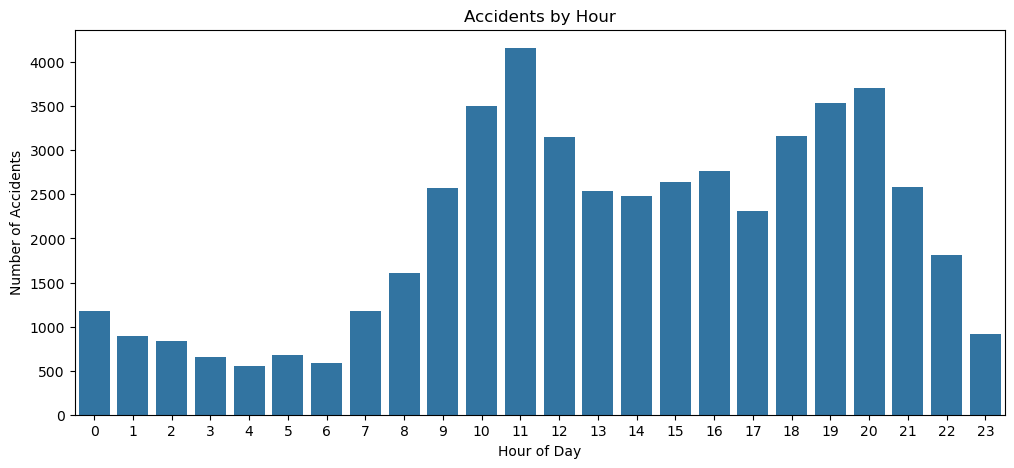

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.countplot(data=df, x="Hour")
plt.title("Accidents by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.show()

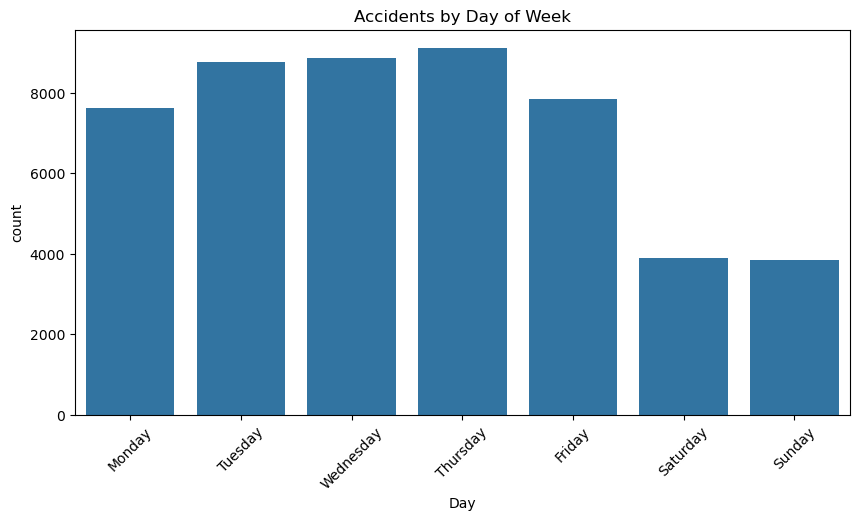

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Day",
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Accidents by Day of Week")
plt.xticks(rotation=45)
plt.show()

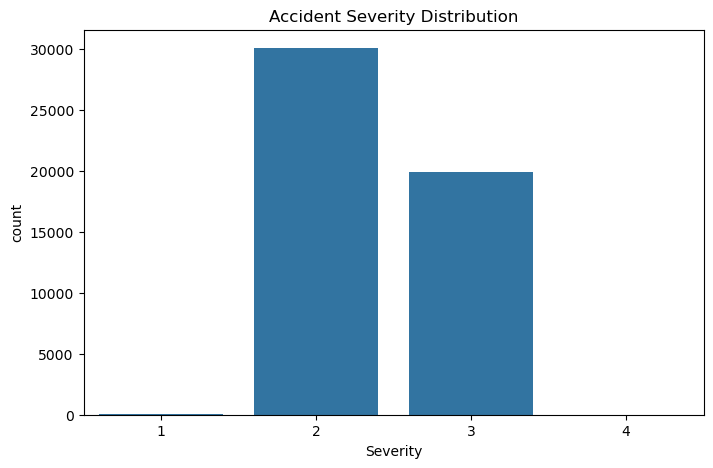

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Severity")
plt.title("Accident Severity Distribution")
plt.show()

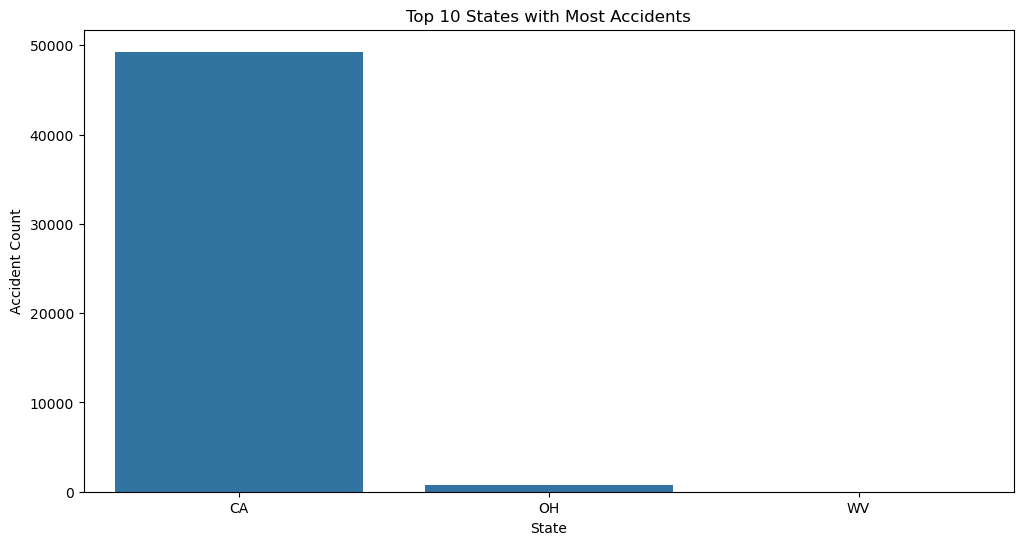

In [13]:
plt.figure(figsize=(12,6))

top_states = df["State"].value_counts().head(10)

sns.barplot(x=top_states.index,
            y=top_states.values)

plt.title("Top 10 States with Most Accidents")
plt.xlabel("State")
plt.ylabel("Accident Count")

plt.show()

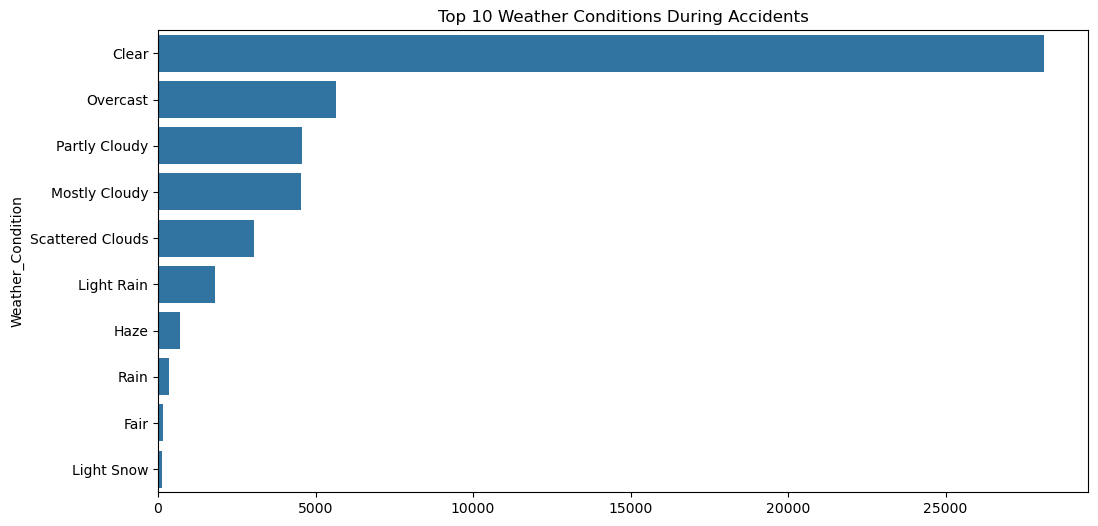

In [14]:
plt.figure(figsize=(12,6))

weather = df["Weather_Condition"].value_counts().head(10)

sns.barplot(y=weather.index,
            x=weather.values)

plt.title("Top 10 Weather Conditions During Accidents")

plt.show()

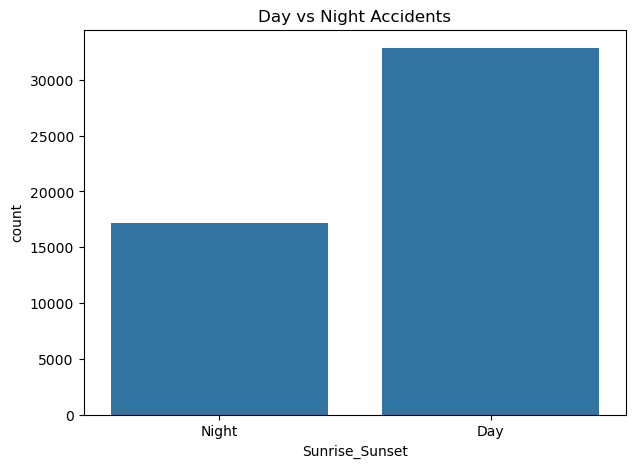

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x="Sunrise_Sunset")

plt.title("Day vs Night Accidents")

plt.show()

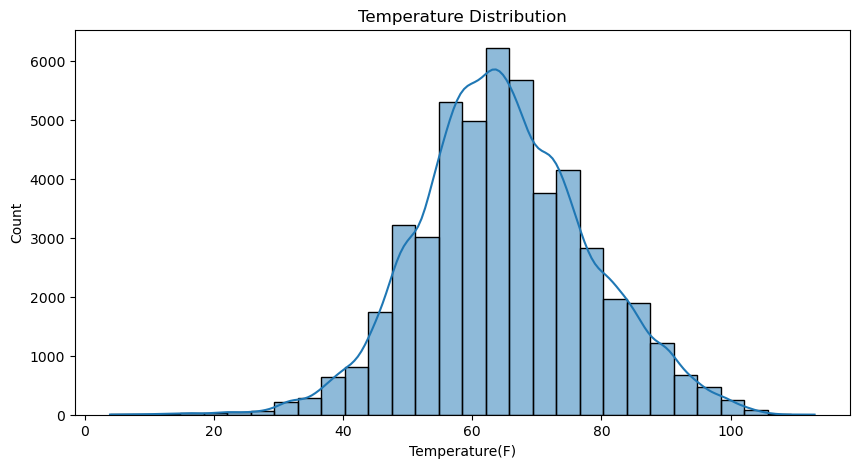

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df["Temperature(F)"],
             bins=30,
             kde=True)

plt.title("Temperature Distribution")

plt.show()

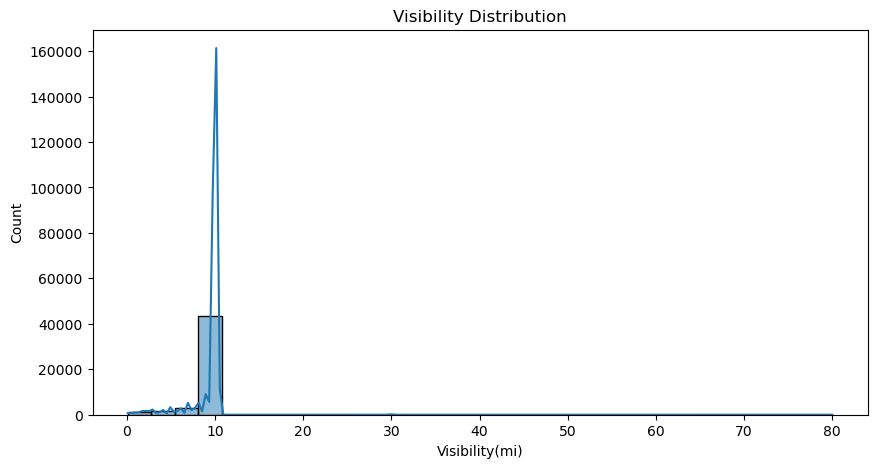

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df["Visibility(mi)"],
             bins=30,
             kde=True)

plt.title("Visibility Distribution")

plt.show()

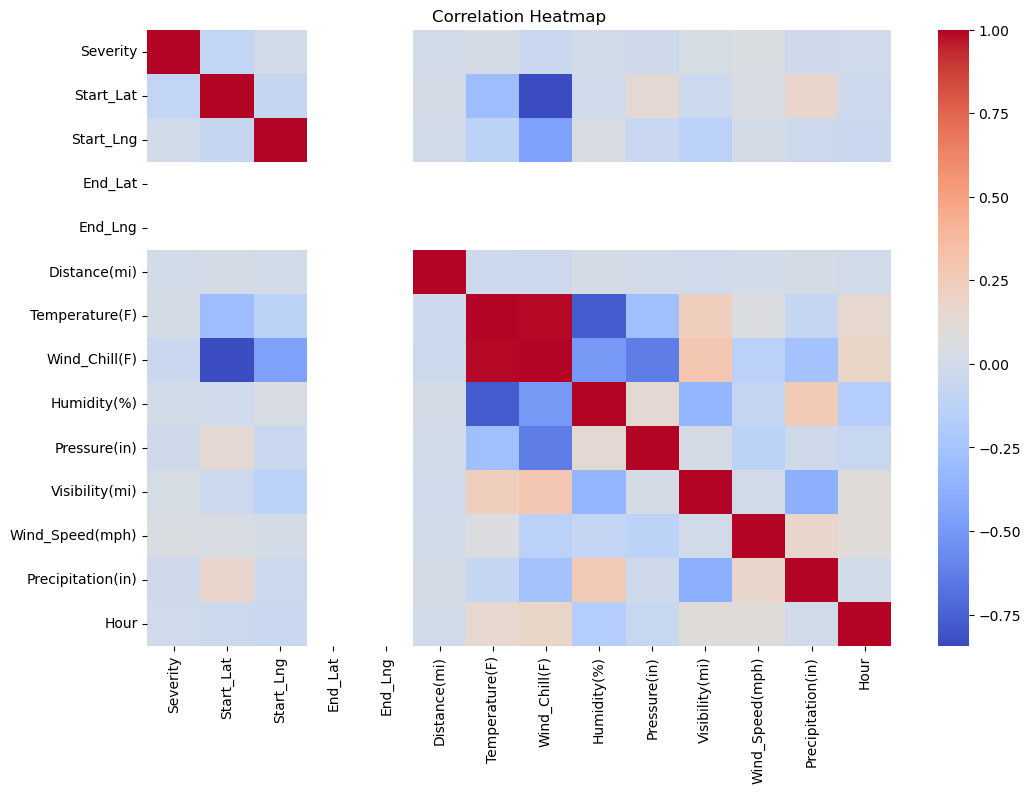

In [18]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(numeric.corr(),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

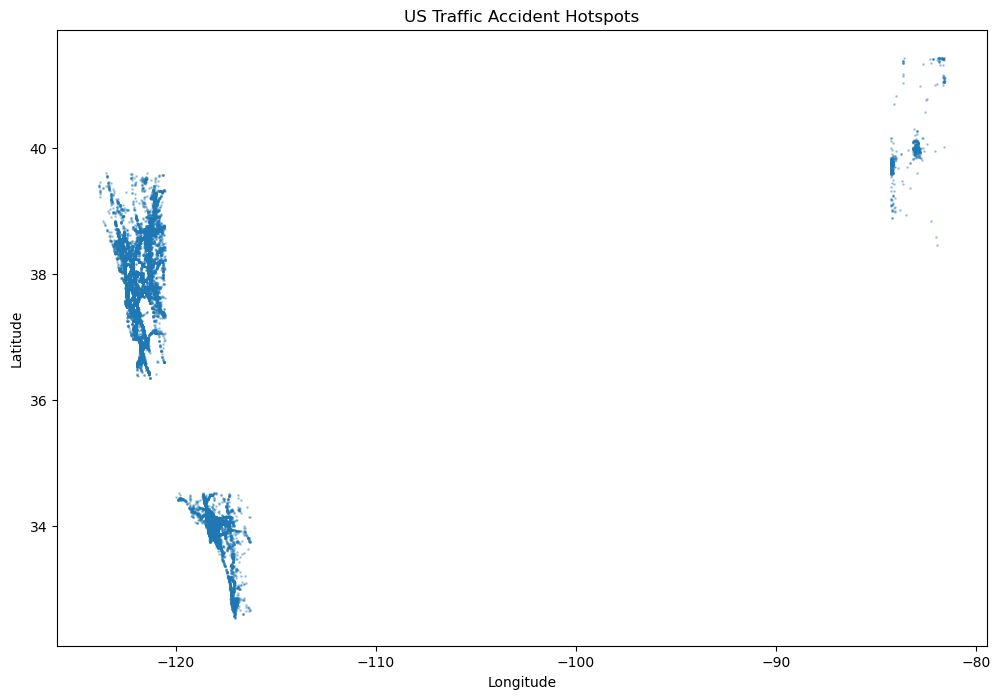

In [19]:
plt.figure(figsize=(12,8))

plt.scatter(df["Start_Lng"],
            df["Start_Lat"],
            s=1,
            alpha=0.3)

plt.title("US Traffic Accident Hotspots")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

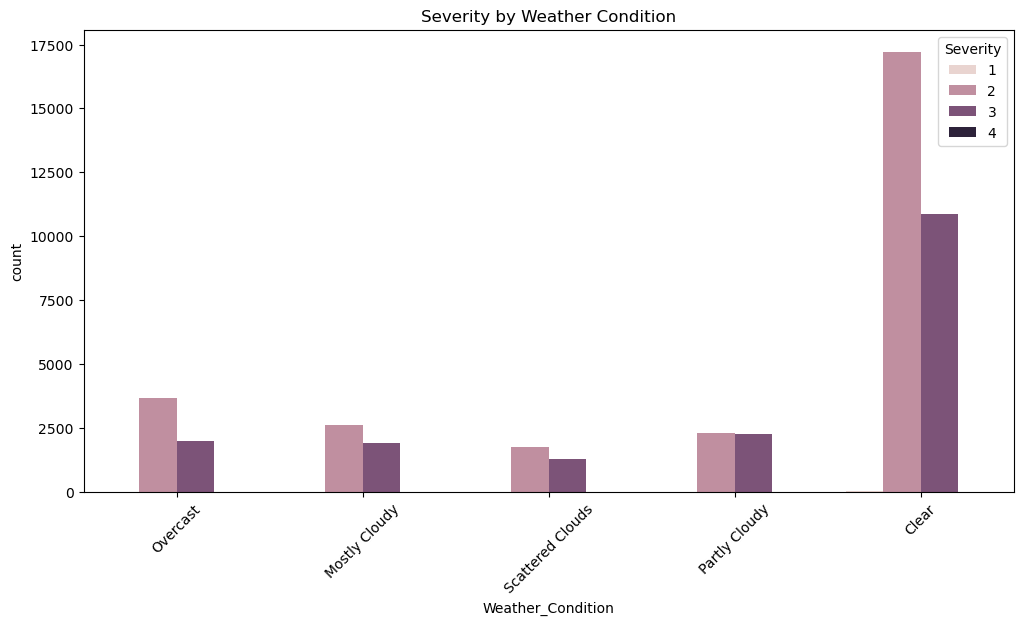

In [20]:
top_weather = df["Weather_Condition"].value_counts().head(5).index

filtered = df[df["Weather_Condition"].isin(top_weather)]

plt.figure(figsize=(12,6))

sns.countplot(data=filtered,
              x="Weather_Condition",
              hue="Severity")

plt.xticks(rotation=45)

plt.title("Severity by Weather Condition")

plt.show()

In [21]:
# Missing Values

missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

print(missing)

End_Lat              50000
End_Lng              50000
Wind_Chill(F)        47503
Precipitation(in)    46724
Wind_Speed(mph)       8422
Humidity(%)            639
Weather_Condition      603
Visibility(mi)         526
Temperature(F)         456
Pressure(in)           306
Wind_Direction         267
Weather_Timestamp      266
Timezone                 7
Airport_Code             7
Zipcode                  7
dtype: int64


In [22]:
# Duplicate Records

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [23]:
# Summary Statistics

print(df.describe())

          Severity                     Start_Time     Start_Lat     Start_Lng  \
count  50000.00000                          50000  50000.000000  50000.000000   
mean       2.39678  2016-08-19 00:08:43.241720064     37.396862   -120.736826   
min        1.00000            2016-02-08 05:46:00     32.544304   -123.813927   
25%        2.00000  2016-06-21 10:49:19.249999872     37.343647   -122.127098   
50%        2.00000            2016-08-10 18:46:35     37.776711   -121.828537   
75%        3.00000            2016-11-03 12:17:41     38.409191   -121.272102   
max        4.00000            2017-01-26 20:02:26     41.428753    -81.550728   
std        0.49225                            NaN      1.553001      4.750326   

       End_Lat  End_Lng  Distance(mi)  Temperature(F)  Wind_Chill(F)  \
count      0.0      0.0  50000.000000    49544.000000    2497.000000   
mean       NaN      NaN      0.014660       64.975323      39.050541   
min        NaN      NaN      0.000000        3.900000 

In [25]:
print("""
KEY INSIGHTS

1. Accident frequency increased during peak commuting hours.
2. Severity Level 2 accidents were the most common.
3. Certain states recorded significantly higher accident counts.
4. Fair, Cloudy, Rain, and Fog were the most common weather conditions during accidents.
5. Urban regions showed higher accident concentrations.
6. Reduced visibility contributed to increased accident occurrence.
7. Daytime accidents were more frequent than nighttime accidents.
8. The analysis helps identify factors affecting road safety.
""")


KEY INSIGHTS

1. Accident frequency increased during peak commuting hours.
2. Severity Level 2 accidents were the most common.
3. Certain states recorded significantly higher accident counts.
4. Fair, Cloudy, Rain, and Fog were the most common weather conditions during accidents.
5. Urban regions showed higher accident concentrations.
6. Reduced visibility contributed to increased accident occurrence.
7. Daytime accidents were more frequent than nighttime accidents.
8. The analysis helps identify factors affecting road safety.



In [26]:
print("""
CONCLUSION

This project analyzed the US Traffic Accidents dataset using Python, Pandas, Matplotlib, and Seaborn. The analysis identified accident patterns based on weather conditions, time of day, location, and severity. Visualizations revealed accident hotspots and key contributing factors. The findings can support better traffic management, road safety planning, and data-driven decision-making.
""")


CONCLUSION

This project analyzed the US Traffic Accidents dataset using Python, Pandas, Matplotlib, and Seaborn. The analysis identified accident patterns based on weather conditions, time of day, location, and severity. Visualizations revealed accident hotspots and key contributing factors. The findings can support better traffic management, road safety planning, and data-driven decision-making.

